# Regression Head Diagnosis

## 0. Setup

In [1]:
import csv
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

FUSION_OUT = RUNS / "04_fusion_model"
RUN_KEY = "model_a_winner"
OUT_DIR = RUNS / "12_regression_diagnosis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FAILURES = []


Device: mps


# Target Distribution

112 day-entries with a valid days_until_spoilage value

Overall: mean=15.74, std=20.21, min=0.00, max=65.00

Per-fruit breakdown:
                   count       mean        std  min   max
fruit                                                    
Banana                 7   1.285714   1.704336  0.0   4.0
Carrot                 9   0.555556   1.130388  0.0   3.0
Guava                 10   1.400000   1.955050  0.0   5.0
Indian_Gooseberry     30   6.700000   7.349173  0.0  21.0
Mango                  8   3.750000   3.535534  0.0   9.0
Tomato                48  31.333333  21.996454  0.0  65.0


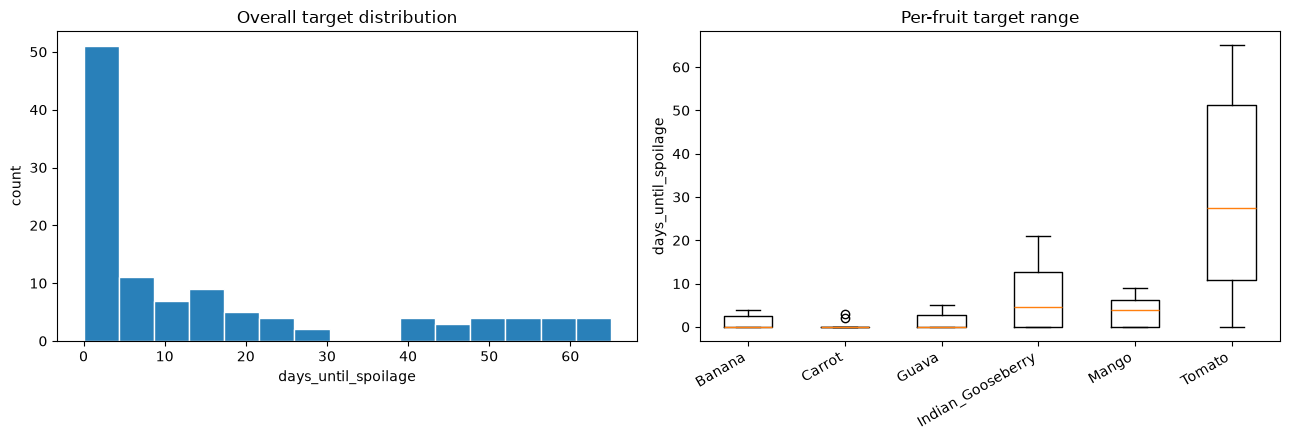

In [2]:
with open(MANIFEST, newline="") as f:
    raw_rows = list(csv.DictReader(f))

def safe_float(v, default=None):
    try:
        return float(v)
    except Exception:
        return default

target_rows = []
for r in raw_rows:
    if r.get("exclude", "").strip().lower() == "true":
        continue
    dus = safe_float(r.get("days_until_spoilage", ""))
    if dus is None or dus < 0:
        continue
    target_rows.append({"fruit": r["fruit"], "split": r.get("split", "").strip().lower(),
                         "days_until_spoilage": dus})

target_df = pd.DataFrame(target_rows)
print(f"{len(target_df)} day-entries with a valid days_until_spoilage value")
print(f"\nOverall: mean={target_df['days_until_spoilage'].mean():.2f}, "
      f"std={target_df['days_until_spoilage'].std():.2f}, "
      f"min={target_df['days_until_spoilage'].min():.2f}, max={target_df['days_until_spoilage'].max():.2f}")

per_fruit = target_df.groupby("fruit")["days_until_spoilage"].agg(["count", "mean", "std", "min", "max"])
print("\nPer-fruit breakdown:")
print(per_fruit.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(target_df["days_until_spoilage"], bins=15, color="#2980b9", edgecolor="white")
axes[0].set_xlabel("days_until_spoilage"); axes[0].set_ylabel("count")
axes[0].set_title("Overall target distribution")

fruits = sorted(target_df["fruit"].unique())
axes[1].boxplot([target_df[target_df["fruit"] == f]["days_until_spoilage"] for f in fruits],
                 tick_labels=fruits)
axes[1].set_ylabel("days_until_spoilage")
axes[1].set_title("Per-fruit target range")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_target_distribution.png", dpi=150)
plt.show()

## Data

In [3]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def get_rgb_transform():
    return transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
                                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])


def get_ir_transform():
    return transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
                                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])


class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, split=None, gas_norm_stats_path=None,
                 shared_pixel_cache=None):
        self.root = Path(root)
        self.rgb_transform = get_rgb_transform(); self.ir_transform = get_ir_transform()
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self._image_cache = {}; self._build_image_index()
        self._pixel_cache = shared_pixel_cache if shared_pixel_cache is not None else {}
        if shared_pixel_cache is None:
            self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions (split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            dus = None
            try:
                dus = float(row.get('days_until_spoilage', ''))
            except Exception:
                dus = -1.0
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                def sf(v, d=0.0):
                    try:
                        return float(v)
                    except Exception:
                        return d
                ir_avail = sf(row.get(f'ir_{session}_count', 0)) > 0
                srgb_avail = sf(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': dus,
                    'gas_mean': sf(row.get(f'methane_{session}_ppm', '')), 'gas_std': sf(row.get(f'methane_{session}_std', '')),
                    'gas_left': sf(row.get(f'methane_{session}_left', '')), 'gas_right': sf(row.get(f'methane_{session}_right', '')),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        img = transform(Image.open(path).convert('RGB'))
        return img

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        for path in all_paths:
            try:
                img = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))(Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass

    def _norm_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})
        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        cached = self._image_cache.get((s['fruit'], s['label'], s['actual_date'], s['session']), {'rgb': [], 'ir': []})
        rgb_avail = s['rgb_available'] and bool(cached['rgb'])
        ir_avail = s['ir_available'] and bool(cached['ir'])
        rgb_t = torch.stack([self._load(p, self.rgb_transform) for p in cached['rgb']]) if rgb_avail else torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        ir_t = torch.stack([self._load(p, self.ir_transform) for p in cached['ir']]) if ir_avail else torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if s['gas_available']:
            m, sd, l, r = self._norm_gas(s['fruit'], s['session'], s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(s['session_idx']) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_t, 'ir_images': ir_t, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(s['gas_available'], dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(s['session_idx'], dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': s['fruit'], 'actual_date': s['actual_date'], 'corrected_day_index': s['corrected_day_index']}


class DayLevelSequenceDataset(Dataset):
    def __init__(self, split="train", shared_pixel_cache=None):
        base = TrimodalDataset(MANIFEST, ROOT, split=split, gas_norm_stats_path=GAS_NORM,
                                shared_pixel_cache=shared_pixel_cache)
        self._pixel_cache = base._pixel_cache
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail, "fruit_idx": sessions[0]["fruit_idx"],
                "label": sessions[0]["label"], "days_until": sessions[0]["days_until_spoilage"], "fruit": fruit,
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        print(f"  DayLevelSequenceDataset: {len(self.trajectories)} trajectories (split={split})")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE); blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {"rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
                "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
                "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"], "days_until": traj[-1]["days_until"],
                "fruit": self.trajectories[idx]["fruit"]}


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE); ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool); ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6); gas_mask = torch.zeros(B, max_T); gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long); label = torch.zeros(B, dtype=torch.long); days_until = torch.zeros(B, dtype=torch.float32)
    fruits = []
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
        fruits.append(b.get("fruit"))
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until, "fruit": fruits}


## Model

In [4]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))
    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)
    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280}


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        out = backbone(torch.zeros(1, 3, img_size, img_size))
    return out.shape[1]


def build_cnn_backbone(name):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return base.features, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
        feat_dim = _infer_feature_dim(backbone)
        BACKBONE_FEATURE_DIMS[name] = feat_dim
        return backbone, feat_dim
    raise ValueError(f"Unknown backbone: {name}")


class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True, use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        self.chunk_size = chunk_size
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, seq):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        return torch.cat(feats_list, dim=0).view(B, T, -1)


class GRUDCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, x_mean=None):
        super().__init__()
        self.input_dim = input_dim; self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)
    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)
    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


class CrossModalFusion(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
        avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
        key_padding_mask = ~avail
        fully_missing = key_padding_mask.all(dim=1)
        if fully_missing.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[fully_missing] = False
        attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                      need_weights=True, average_attn_weights=True)
        out = self.norm(tokens + attended)
        return out.mean(dim=1), attn_w


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-__import__("math").log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512, dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
    def forward(self, z_seq, pad_mask):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


def gather_last_valid(H, pad_mask):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


class TrimodalFusionModel(nn.Module):
    def __init__(self, rgb_backbone_name="convnext_tiny", ir_backbone_name="efficientnet_b0",
                 d_model=64, gas_hidden=64, num_heads=4, temporal_layers=2,
                 dropout=0.5, cls_dropout=0.5, freeze_visual_backbone=True):
        super().__init__()
        self.d_model = d_model
        self.rgb_encoder = VisualEncoderToggle(rgb_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.ir_encoder = VisualEncoderToggle(ir_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)
        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.fusion = CrossModalFusion(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.temporal = TemporalTransformer(d_model=d_model, nhead=num_heads, num_layers=temporal_layers, dropout=dropout)
        self.cls_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 2))
        self.reg_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 1), nn.ReLU())
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def forward(self, batch):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape
        rgb_feat = self.rgb_encoder(rgb_seq); ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)
        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)
        rgb_flat = rgb_proj.reshape(B * T, -1); ir_flat = ir_proj.reshape(B * T, -1); gas_flat = gas_proj.reshape(B * T, -1)
        rgb_av_flat = rgb_avail.reshape(B * T); ir_av_flat = ir_avail.reshape(B * T); gas_av_flat = gas_mask.reshape(B * T).bool()
        z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
        z_seq = z_flat.reshape(B, T, -1)
        H = self.temporal(z_seq, pad_mask)
        H_T, last_idx = gather_last_valid(H, pad_mask)
        cls_logits = self.cls_head(H_T); reg_output = self.reg_head(H_T)
        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))
        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}

In [5]:
D_MODEL, DROPOUT = 64, 0.5

train_ds = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)
test_ds = DayLevelSequenceDataset(split="test", shared_pixel_cache=train_ds._pixel_cache)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=False, collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=day_sequence_collate, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=day_sequence_collate, num_workers=0)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)} trajectories")


def collect_reg_preds(model, loader):
    model.eval()
    days_gt, days_pred, fruits = [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
            fruits.extend(batch["fruit"])
    return np.array(days_gt), np.array(days_pred), fruits


ensemble_train_pred, ensemble_val_pred, ensemble_test_pred = None, None, None
train_gt, val_gt, test_gt = None, None, None
train_fruits, val_fruits, test_fruits = None, None, None

seed_train_preds, seed_val_preds, seed_test_preds = [], [], []
for seed in range(10):
    ckpt_path = FUSION_OUT / RUN_KEY / f"seed_{seed}" / "model_state.pt"
    if not ckpt_path.exists():
        print(f"  [SKIP] seed {seed}: checkpoint not found")
        continue
    try:
        model = TrimodalFusionModel(d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
                                     freeze_visual_backbone=True).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        tr_gt, tr_pred, tr_fruits = collect_reg_preds(model, train_loader)
        va_gt, va_pred, va_fruits = collect_reg_preds(model, val_loader)
        te_gt, te_pred, te_fruits = collect_reg_preds(model, test_loader)

        seed_train_preds.append(tr_pred); seed_val_preds.append(va_pred); seed_test_preds.append(te_pred)
        train_gt, val_gt, test_gt = tr_gt, va_gt, te_gt
        train_fruits, val_fruits, test_fruits = tr_fruits, va_fruits, te_fruits
        del model
        print(f"  seed {seed}: collected")
    except Exception as e:
        import traceback
        tb = traceback.format_exc()
        print(f"  [FAIL] seed {seed}: {type(e).__name__}: {e}")
        FAILURES.append({"seed": seed, "type": type(e).__name__, "message": str(e), "traceback": tb})

ensemble_train_pred = np.mean(seed_train_preds, axis=0)
ensemble_val_pred = np.mean(seed_val_preds, axis=0)
ensemble_test_pred = np.mean(seed_test_preds, axis=0)
print(f"\n{len(seed_train_preds)} seeds collected across train/val/test.")


TrimodalDataset: 212 sessions (split=train)
  DayLevelSequenceDataset: 12 trajectories (split=train)
TrimodalDataset: 63 sessions (split=val)
  DayLevelSequenceDataset: 12 trajectories (split=val)
TrimodalDataset: 52 sessions (split=test)
  DayLevelSequenceDataset: 11 trajectories (split=test)
train: 12 | val: 12 | test: 11 trajectories


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2067/221959471.py:163: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  seed 0: collected
  seed 1: collected
  seed 2: collected
  seed 3: collected
  seed 4: collected
  seed 5: collected
  seed 6: collected
  seed 7: collected
  seed 8: collected
  seed 9: collected

10 seeds collected across train/val/test.


In [6]:
def reg_metrics(gt, pred):
    return {"mae": mean_absolute_error(gt, pred), "rmse": mean_squared_error(gt, pred) ** 0.5,
            "r2": r2_score(gt, pred)}

train_metrics = reg_metrics(train_gt, ensemble_train_pred)
val_metrics = reg_metrics(val_gt, ensemble_val_pred)
test_metrics = reg_metrics(test_gt, ensemble_test_pred)

print("=" * 90)
print("  TRAIN vs. VAL vs. TEST -- regression head")
print("=" * 90)
print(f"{'Split':<10}{'MAE':>10}{'RMSE':>10}{'R2':>10}{'n':>6}")
for name, m, gt in [("train", train_metrics, train_gt), ("val", val_metrics, val_gt), ("test", test_metrics, test_gt)]:
    print(f"{name:<10}{m['mae']:>10.4f}{m['rmse']:>10.4f}{m['r2']:>10.4f}{len(gt):>6}")


  TRAIN vs. VAL vs. TEST -- regression head
Split            MAE      RMSE        R2     n
train         3.2656    5.3948   -0.2704    12
val           2.0852    3.0189   -0.2475    12
test          0.9188    1.0593    0.0439    11


In [7]:
global_mean_train = train_gt.mean()

def fruit_mean_predict(fruits, gt_lookup):
    return np.array([gt_lookup.get(f, global_mean_train) for f in fruits])

per_fruit_train_mean = {}
for f in set(train_fruits):
    per_fruit_train_mean[f] = train_gt[np.array(train_fruits) == f].mean()

results_rows = []
for split_name, gt, fruits, model_pred in [
    ("train", train_gt, train_fruits, ensemble_train_pred),
    ("val", val_gt, val_fruits, ensemble_val_pred),
    ("test", test_gt, test_fruits, ensemble_test_pred),
]:
    global_pred = np.full_like(gt, global_mean_train)
    fruit_pred = fruit_mean_predict(fruits, per_fruit_train_mean)

    for method_name, pred in [("trained_model", model_pred), ("global_mean_baseline", global_pred),
                               ("per_fruit_mean_baseline", fruit_pred)]:
        m = reg_metrics(gt, pred)
        results_rows.append({"split": split_name, "method": method_name, **m})

baseline_df = pd.DataFrame(results_rows)
baseline_df.to_csv(OUT_DIR / "regression_baseline_comparison.csv", index=False)

print("=" * 90)
print("  TRAINED MODEL vs. BASELINES")
print("=" * 90)
for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}:")
    sub = baseline_df[baseline_df["split"] == split_name]
    print(sub[["method", "mae", "rmse", "r2"]].to_string(index=False))

test_sub = baseline_df[baseline_df["split"] == "test"].set_index("method")
model_r2 = test_sub.loc["trained_model", "r2"]
fruit_baseline_r2 = test_sub.loc["per_fruit_mean_baseline", "r2"]
print(f"\nTest: trained model R2={model_r2:.4f}, per-fruit-mean baseline R2={fruit_baseline_r2:.4f}")


  TRAINED MODEL vs. BASELINES

TRAIN:
                 method      mae     rmse        r2
          trained_model 3.265625 5.394801 -0.270373
   global_mean_baseline 3.486111 4.786410  0.000000
per_fruit_mean_baseline 3.416667 4.158325  0.245226

VAL:
                 method      mae     rmse        r2
          trained_model 2.085185 3.018873 -0.247488
   global_mean_baseline 2.541667 2.977928 -0.213878
per_fruit_mean_baseline 2.166667 3.034524 -0.260456

TEST:
                 method      mae     rmse         r2
          trained_model 0.918824 1.059262   0.043898
   global_mean_baseline 2.507576 2.731573  -5.358030
per_fruit_mean_baseline 2.681818 3.720337 -10.794014

Test: trained model R2=0.0439, per-fruit-mean baseline R2=-10.7940


## Summary

In [8]:
print("SUMMARY: why is the regression head weak?")
print(f"\nTarget distribution: per-fruit ranges shown in Part 1")
print(f"\nTrain R2={train_metrics['r2']:.4f}, Val R2={val_metrics['r2']:.4f}, Test R2={test_metrics['r2']:.4f}")
print(f"Trained model vs. per-fruit-mean baseline (test): {model_r2:.4f} vs. {fruit_baseline_r2:.4f}")
if FAILURES:
    print(f"\n{len(FAILURES)} failure(s) logged -- see FAILURES for full type/message/traceback.")
print(f"\nAll outputs saved under: {OUT_DIR}")


SUMMARY: why is the regression head weak?

Target distribution: per-fruit ranges shown in Part 1

Train R2=-0.2704, Val R2=-0.2475, Test R2=0.0439
Trained model vs. per-fruit-mean baseline (test): 0.0439 vs. -10.7940

All outputs saved under: /Users/sjanani2073/Desktop/convscript/runs/12_regression_diagnosis
